Из прошлой лабораторной возмем класс Matrix для дальнейшего использования и изменения в этой лабораторной:

In [1]:
import copy
import math
import pandas as pd
class MatrixError(Exception):
    def __init__(self, message):
        super().__init__(message)

class Matrix:
    def __init__(self, height, width, matrix):
        self.width = width
        self.height = height
        self.matrix = matrix

    def __str__(self):
        '''Просто более красивый вывод матрицы'''
        max_len = max(len(f"{element:.2f}") for row in self.matrix for element in row)
        border = "+" + ("-" * (max_len + 2) + "+") * self.width
        formatted_width = [border]
        for row in self.matrix:
            elements = "| " + " | ".join(f"{element:>{max_len}.2f}" for element in row) + " |"
            formatted_width.extend([elements, border])
        return "\n".join(formatted_width)

    def __add__(self, other):
        '''Обычное сложение матриц'''
        if self.width != other.width or self.height != other.height:
            raise MatrixError("Матрицы должны быть одного размера!")

        new_matrix = [
            [self.matrix[i][j] + other.matrix[i][j] for j in range(self.width)]
            for i in range(self.height)
        ]
        return Matrix(self.height, self.width, new_matrix)

    def __mul__(self, other):
        '''Обычное умножение матрицы на скаляр или матрицу'''
        if type(other) != Matrix:
            new = [[self.matrix[i][j] * other for j in range(self.width)] for i in range(self.height)]
            return Matrix(self.height, self.width, new)
        else:
            if self.width != other.height:
                raise MatrixError ("Число столбцов в первом сомножителе должно быть равно числу строк во втором!")
            new = [
                [sum([self.matrix[i][k] * other.matrix[k][j] for k in range(self.width)])for j in range(other.width)]
                for i in range(self.height)
            ]

            return Matrix(self.height, other.width, new)


    def determinant(self):
        """Вычисляет определитель квадратной матрицы рекурсивным методом (разложение по строке)"""
        if self.height != self.width:
            raise MatrixError("Матрица должна быть квадратной для вычисления определителя.")

        n = self.height
        matrix_copy_data = copy.deepcopy(self.matrix)
        matrix_copy = Matrix(n, n, matrix_copy_data)
        swaps_count = 0 

        for i in range(n):
            pivot_row = i
            for k in range(i + 1, n):
                if abs(matrix_copy.matrix[k][i]) > abs(matrix_copy.matrix[pivot_row][i]):
                    pivot_row = k

            if matrix_copy.matrix[pivot_row][i] == 0:
                return 0.0 

            if pivot_row != i:
                matrix_copy.matrix[i], matrix_copy.matrix[pivot_row] = matrix_copy.matrix[pivot_row], matrix_copy.matrix[i]
                swaps_count += 1 

            for k in range(i + 1, n):
                factor = matrix_copy.matrix[k][i] / matrix_copy.matrix[i][i]
                for j in range(i, n):
                    matrix_copy.matrix[k][j] -= factor * matrix_copy.matrix[i][j]

        determinant = 1.0
        for i in range(n):
            determinant *= matrix_copy.matrix[i][i] 
        if swaps_count % 2 != 0:
            determinant *= -1.0

        return determinant
    
    def mean (self):
        new = copy.deepcopy(self.matrix)
        mean = []
        s = count = 0

        for j in range(self.width):
            for i in range(self.height):
                if not math.isnan(new[i][j]): 
                    count += 1
                    s += new[i][j]
            if count > 0:
                mean.append(s/count)
            else:
                mean.append(0.0)
            s = 0
            count = 0

        return mean

    def trans(self):
        '''Транспонирование матрицы'''
        new = [
            [self.matrix[i][j] for i in range(self.height)] for j in range(self.width)
        ]
        return Matrix(self.width, self.height, new)


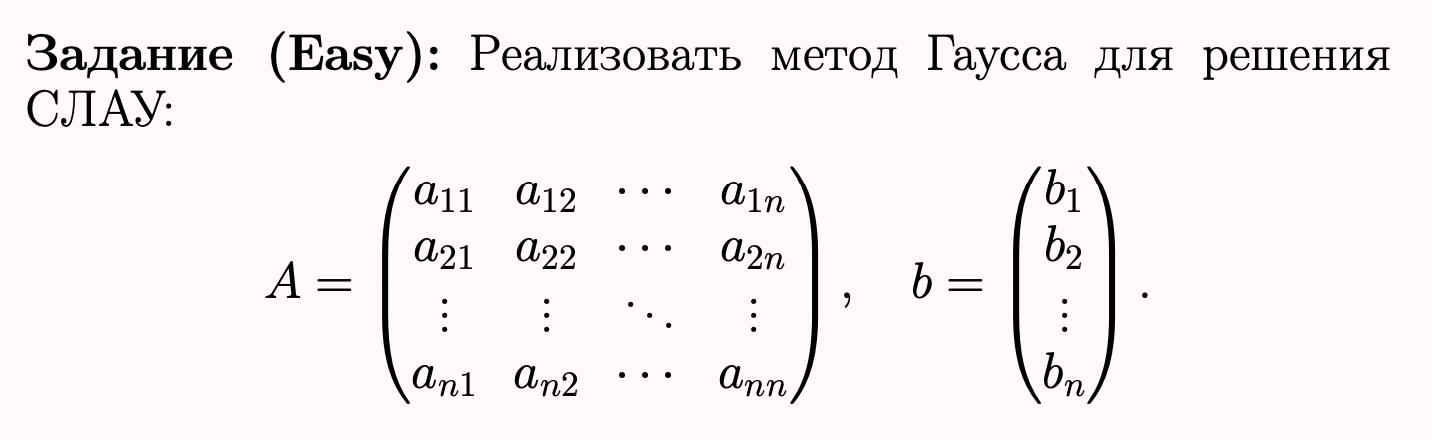

In [2]:
from typing import List

class Matrix(Matrix):
    def gauss_solver(self, b) -> List['Matrix']:
        """Решает СЛАУ методом Гаусса, возвращает базисные векторы"""
        if self.width != self.height:
            raise MatrixError("Матрица коэффициентов должна быть квадратной")
        if b.height != self.height or b.width != 1:
            raise MatrixError("Вектор b должен быть вектор-столбцом с тем же числом строк")

        n = self.width
        Ab = [self.matrix[i] + [b.matrix[i][0]] for i in range(n)]
        rank = 0

        # Прямой ход метода Гаусса
        for col in range(n):
            pivot_row = max(range(rank, n), key=lambda r: abs(Ab[r][col]), default=rank)

            if abs(Ab[pivot_row][col]) < 1e-10:
                continue

            Ab[rank], Ab[pivot_row] = Ab[pivot_row], Ab[rank]
            pivot = Ab[rank][col]
            Ab[rank] = [x / pivot for x in Ab[rank]]

            for row in range(n):
                if row != rank and abs(Ab[row][col]) > 1e-10:
                    factor = Ab[row][col]
                    Ab[row] = [Ab[row][j] - factor * Ab[rank][j] for j in range(n+1)]

            rank += 1

        # Находим базисные и свободные переменные
        lead_vars = []
        for row in range(rank):
            for col in range(n):
                if abs(Ab[row][col]) > 1e-10:
                    lead_vars.append(col)
                    break

        free_vars = [col for col in range(n) if col not in lead_vars]
        basis = []

        # Находим частное решение
        particular = [0.0] * n
        for row in reversed(range(rank)):
            lead_col = lead_vars[row]
            particular[lead_col] = Ab[row][-1] - sum(Ab[row][j] * particular[j] for j in range(lead_col+1, n))

        # Находим базисные векторы
        for free in free_vars:
            solution = [0.0] * n
            solution[free] = 1.0  

            for row in reversed(range(rank)):
                lead_col = lead_vars[row]
                solution[lead_col] = -sum(Ab[row][j] * solution[j] for j in range(lead_col+1, n))

            basis.append(Matrix(n, 1, [[x] for x in solution]))

        basis.insert(0, Matrix(n, 1, [[x] for x in particular]))

        return basis
    

In [3]:
matrix1 =  Matrix(3, 3, [[1, 2, 3], 
                          [4, 5, 6], 
                          [7, 8, 9]])

b = Matrix(3, 1, [[1],
                  [2],
                  [3]])

matrix2 =  Matrix(3, 3, [[3, 2, 1], 
                         [0, 1, 0], 
                         [7, 8, 9]])
matrix =  Matrix(3, 3, [[4, 2, 1],
                        [2, 3, 0.5],
                        [1, 0.5, 2]])

print(matrix1 * matrix2)
print(matrix1.determinant())

solutions = matrix.gauss_solver(b)
print("Решения системы:")
for i, sol in enumerate(solutions, 1):
    print(f"Решение {i}:")
    print(sol)


+-------+-------+-------+
| 24.00 | 28.00 | 28.00 |
+-------+-------+-------+
| 54.00 | 61.00 | 58.00 |
+-------+-------+-------+
| 84.00 | 94.00 | 88.00 |
+-------+-------+-------+
6.661338147750939e-16
Решения системы:
Решение 1:
+-------+
| -0.52 |
+-------+
|  0.75 |
+-------+
|  1.57 |
+-------+


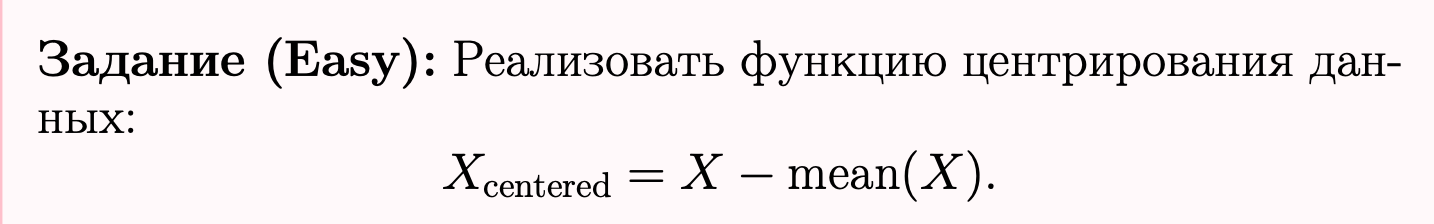

In [4]:
class Matrix(Matrix):
    def center(self):
        '''Центрирование данных'''
        if self.height == 0:
            raise MatrixError("Матрица пуста")
        mean = self.mean()
        new = [
            [self.matrix[i][j] - mean[j] for j in range(self.width)] 
            for i in range(self.height)
        ]
        return Matrix(self.height, self.width, new)

In [5]:
matrix =  Matrix(3, 3, [ [1, 2, 3], 
                          [4, 5, 6], 
                          [7, 8, 9]])

print(matrix.center())

+-------+-------+-------+
| -3.00 | -3.00 | -3.00 |
+-------+-------+-------+
|  0.00 |  0.00 |  0.00 |
+-------+-------+-------+
|  3.00 |  3.00 |  3.00 |
+-------+-------+-------+


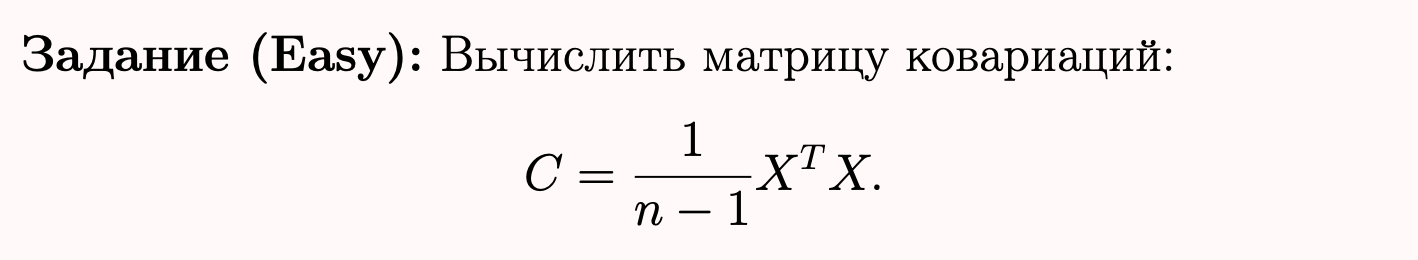

In [6]:
class Matrix(Matrix):
    def correl(self):
        '''Вычисление матрицы ковариляций'''
        if self.height <= 1:
            raise MatrixError("Для вычисления ковариации нужно как минимум 2 наблюдения")
        
        matrix = self.center()
        c = matrix.trans() * matrix

        C = [
            [c.matrix[i][j] / (self.height - 1) for i in range(self.width)] 
            for j in range(self.width)
        ]
        return Matrix(self.width, self.width, C)


In [7]:
matrix =  Matrix(3, 3, [ [1, 2, 3], 
                          [4, 5, 6], 
                          [7, 8, 9]])
data = Matrix(3, 2, [
    [1, 3],
    [2, 5], 
    [4, 7]
])
print(data.trans())
print(data.correl())

+------+------+------+
| 1.00 | 2.00 | 4.00 |
+------+------+------+
| 3.00 | 5.00 | 7.00 |
+------+------+------+
+------+------+
| 2.33 | 3.00 |
+------+------+
| 3.00 | 4.00 |
+------+------+


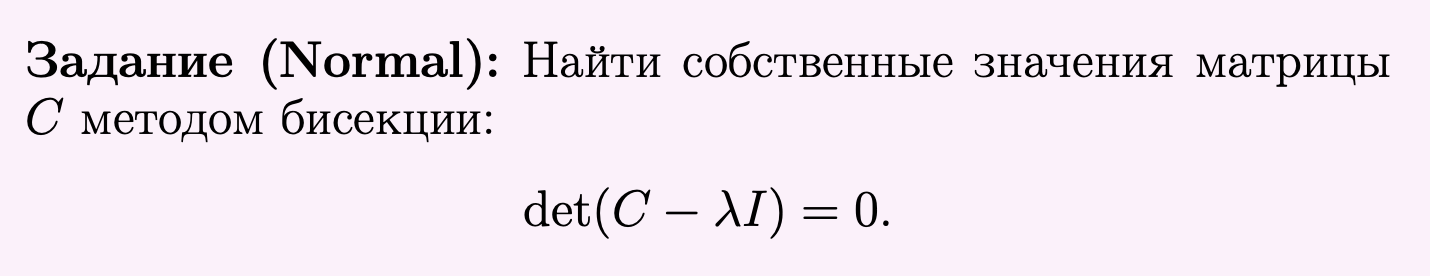

In [8]:
class Matrix(Matrix):
    def polinom(self, lmpd):
        '''Вычисление характеристического многочлена'''
        matrix = [
            [self.matrix[i][j] - (lmpd if i == j else 0) for j in range(self.width)]  
            for i in range(self.height)
        ]
        matrix = Matrix(self.height, self.width, matrix)
        return matrix.determinant()
    
    def find_eigenvalues(self, a, b, eps=1e-6):
        '''Поиск собственных значений на интервале [a, b]'''
        roots = []
        step = (b - a) / 1000
        x1 = a
        y1 = self.polinom(x1)
        
        for _ in range(1000):
            x2 = x1 + step
            if x2 > b:
                break
                
            y2 = self.polinom(x2)
            
            if y1 * y2 < 0:
                root = self.bis(x1, x2, eps)
                if not any(abs(root - r) < eps for r in roots):
                    roots.append(root)
            
            x1, y1 = x2, y2
        
        return roots
    
    def bis(self, a, b, eps):
        '''Метод бисекции для одного корня'''
        ya = self.polinom(a)
        yb = self.polinom(b)
        
        while (b - a) > eps:
            c = (a + b) / 2
            yc = self.polinom(c)
            
            if yc == 0:
                return c
            elif ya * yc < 0:
                b, yb = c, yc
            else:
                a, ya = c, yc
    
        return (a + b) / 2



In [9]:
matrix =  Matrix(3, 3, [[4, 2, 1],
                        [2, 3, 0.5],
                        [1, 0.5, 2]])

val = matrix.find_eigenvalues(-10, 10)
roots = []
for v in val:
    if abs(v) < 1e-4:
        roots.append(float(f"{v:.4e}"))  
    else:
        roots.append(round(v, 4))
for i in range(len(roots)):
    print(f"Корень {i + 1} = {roots[i]}")

Корень 1 = 1.3163
Корень 2 = 1.8112
Корень 3 = 5.8726


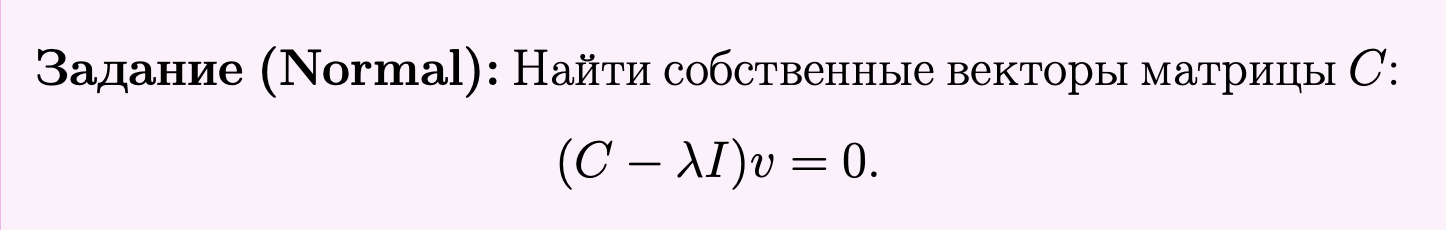

In [10]:
class Matrix(Matrix):
    def find_eigenvectors(self, eigenvalues):
        '''Поиск Собственных векторов матрицы'''
        eigenvectors = []
        for val in eigenvalues:

            matrix = [
                [self.matrix[i][j] - (val if i == j else 0) for j in range(self.width)] 
                for i in range(self.height)
            ]
            b = Matrix(self.height, 1, [[1e-3] for _ in range(self.height)])
            matrix = Matrix(self.height, self.width, matrix)
            
            try:
                solutions = matrix.gauss_solver(b)
                if solutions:
                    for sol in solutions:

                        if not all(abs(x) < 1e-10 for row in sol.matrix for x in row):
                            norm = sum(x*x for row in sol.matrix for x in row) ** 0.5

                            if norm > 1e-10:
                                normalized = [[x/norm] for row in sol.matrix for x in row]
                                eigenvectors.append(Matrix(self.height, 1, normalized))
            except MatrixError as e:
                print(f"Для λ={val}: {e}")
                continue
        
        return eigenvectors
            

In [11]:
matrix =  Matrix(3, 3, [[4, 2, 1],
                        [2, 3, 0.5],
                        [1, 0.5, 2]])

val = matrix.find_eigenvalues(-10, 10)
eigenvectors = matrix.find_eigenvectors(val)
print("\nСобственные векторы:")
for i, vec in enumerate(eigenvectors):
    print(f"Вектор {i+1}:")
    print(vec)



Собственные векторы:
Вектор 1:
+-------+
| -0.63 |
+-------+
|  0.61 |
+-------+
|  0.48 |
+-------+
Вектор 2:
+-------+
| -0.11 |
+-------+
|  0.54 |
+-------+
| -0.83 |
+-------+
Вектор 3:
+-------+
| -0.77 |
+-------+
| -0.58 |
+-------+
| -0.27 |
+-------+


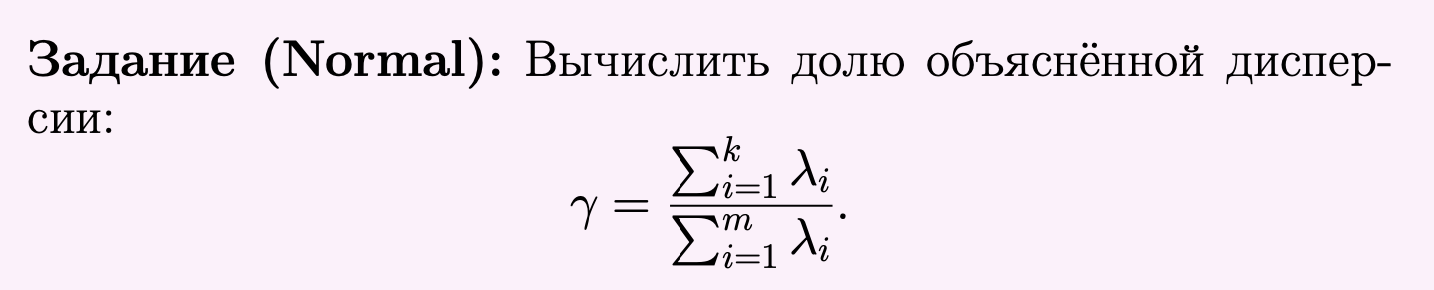

In [12]:
class Matrix (Matrix):
    def dispersion(self, eigenvalues, k):
        values = sorted(eigenvalues, reverse = True)
        # print("Собственные значения (по убыванию):", values)
        sum1 = sum(values)
        k = min(k, len(values))
        sum2 = sum(values[i] for i in range(k))
        return sum2/sum1


In [13]:
matrix =  Matrix(3, 3, [[4, 2, 1],
                        [2, 3, 0.5],
                        [1, 0.5, 2]])
eigenvalues = matrix.find_eigenvalues(-10, 10)
k = 1
dispersion = matrix.dispersion(eigenvalues, k)
print(f"k = {k}: Доля объяснённой дисперсии = {dispersion:.2f} ({dispersion * 100:.1f}%)")

k = 1: Доля объяснённой дисперсии = 0.65 (65.3%)


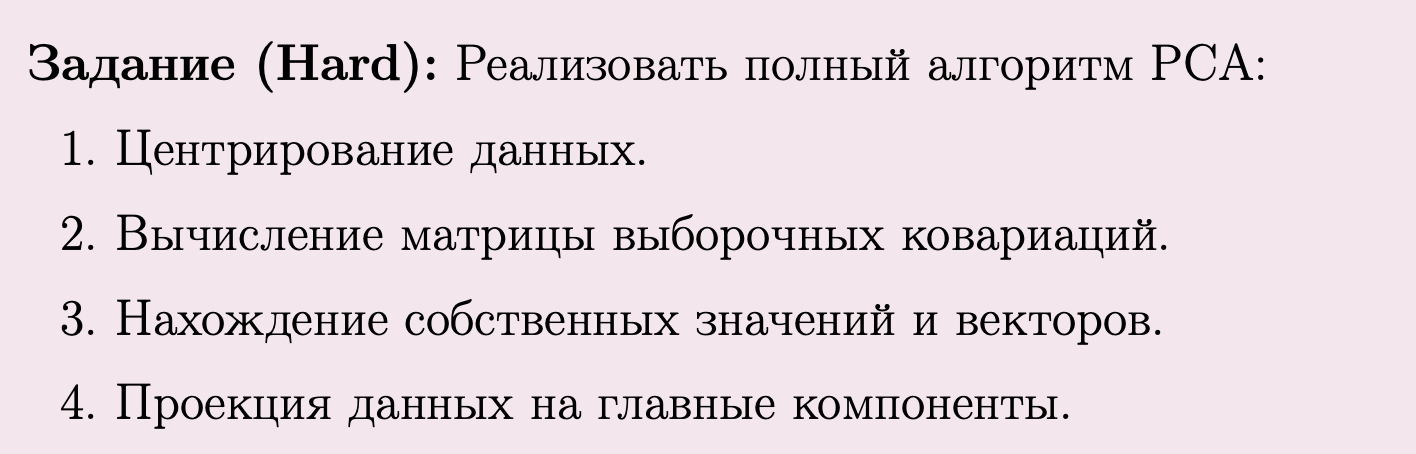

In [14]:
class Matrix (Matrix):
    def PCA(self, k):
        '''Реализация полного алгоритма PCA'''
        # Вычисляем матрицу ковариации
        cov_matrix = self.correl()
        
        # Находим собственные значения и векторы
        eigenvalues = cov_matrix.find_eigenvalues(-10, 10)
        eigenvectors = cov_matrix.find_eigenvectors(eigenvalues)
        
        if not eigenvalues or not eigenvectors:
            raise MatrixError("Не удалось найти собственные значения или векторы")
        
        sorted_pairs = sorted(zip(eigenvalues, eigenvectors), key=lambda x: x[0], reverse=True)
        values_sorted = [val for val, _ in sorted_pairs]
        vectors_sorted = [vec for _, vec in sorted_pairs]
        
        vectors_matrix = Matrix(len(vectors_sorted[0].matrix), len(vectors_sorted), 
                        [[vec.matrix[i][0] for vec in vectors_sorted] for i in range(len(vectors_sorted[0].matrix))])
        k = min(k, len(vectors_sorted))

        dispersion = self.dispersion(values_sorted, k)
        
        first_k_components = Matrix(len(vectors_sorted[0].matrix), k, 
                            [row[:k] for row in vectors_matrix.matrix])
        values_matrix = Matrix(1, len(values_sorted), [values_sorted])
        X_proj = self.center() * first_k_components

        # print("\nРезультаты PCA:")
        # print(f"Количество компонент (k): {k}")
        
        # print("\nСобственные значения (по убыванию):")
        # print(values_matrix)
        
        # print(f"\nДоля объяснённой дисперсии: {dispersion:.2%}")
        
        # print("\nГлавные компоненты (по столбцам):")
        # print(first_k_components)

        # print('\nПроекция данных на главные компоненты:')
        # print(X_proj)
        
        return X_proj, dispersion, first_k_components


In [15]:
matrix =  Matrix(3, 3, [[4, 2, 1],
                        [2, 3, 0.5],
                        [1, 0.5, 2]])
k = 1
ass = matrix.PCA(k)
print(f'\nПроекция данных на главные компоненты:\n{ass[0]}', f"\nДоля объяснённой дисперсии: {ass[1]:.2%}")



Проекция данных на главные компоненты:
+-------+
| -1.38 |
+-------+
| -0.66 |
+-------+
|  2.05 |
+-------+ 
Доля объяснённой дисперсии: 72.62%


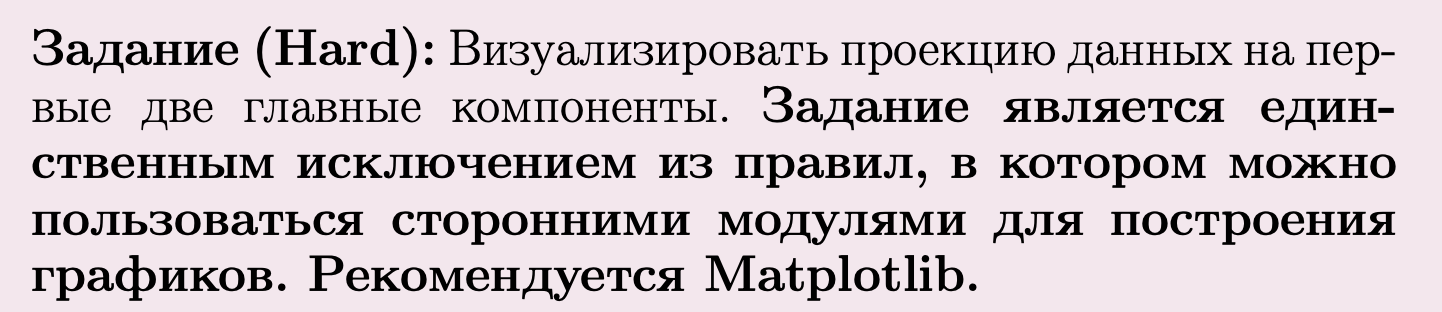

In [16]:
import matplotlib.pyplot as plt
import numpy as np
class Matrix (Matrix):
    def visualization(self, eigenvalues, eigenvectors):
        '''Визуализация результатов PCA'''
        plt.figure(figsize=(12, 5))
        
        # 1. График собственных значений
        plt.subplot(1, 2, 1)
        plt.bar(range(1, len(eigenvalues) + 1), eigenvalues)
        plt.title('Собственные значения')
        plt.xlabel('Номер компоненты')
        plt.ylabel('Значение')
        
        # 2. График накопленной дисперсии
        plt.subplot(1, 2, 2)
        cumulative_variance = np.cumsum(eigenvalues) / np.sum(eigenvalues)
        plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'o-')
        plt.title('Накопленная дисперсия')
        plt.xlabel('Количество компонент')
        plt.ylabel('Доля объясненной дисперсии')
        plt.axhline(y=0.95, color='r', linestyle='--', label='95% дисперсии')
        plt.legend()
        
        plt.tight_layout()
        plt.show()

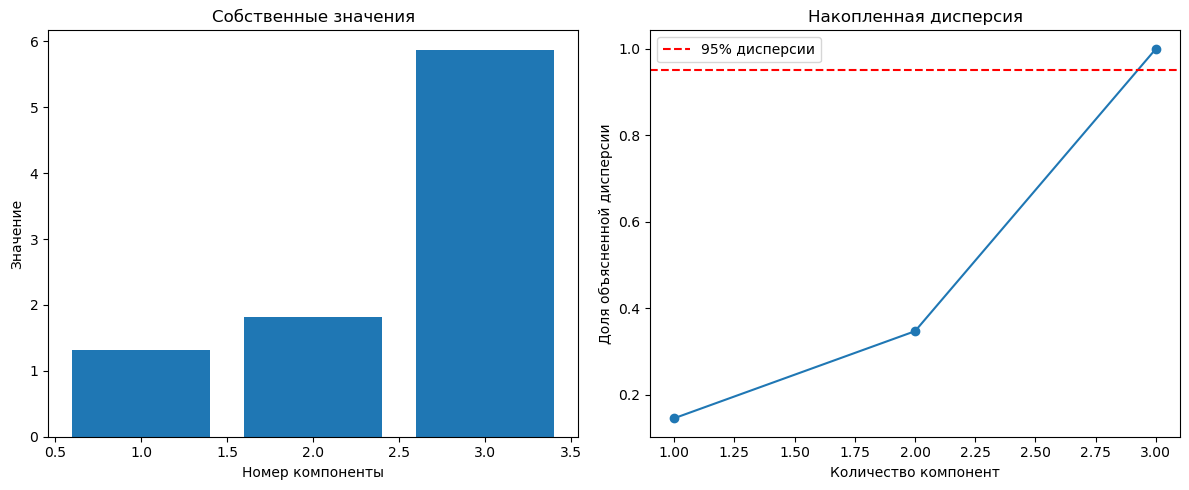

In [17]:
matrix =  Matrix(3, 3, [[4, 2, 1],
                        [2, 3, 0.5],
                        [1, 0.5, 2]])
k = 1
values = matrix.find_eigenvalues(-10, 10)
matrix.visualization(values, matrix.find_eigenvectors(values))

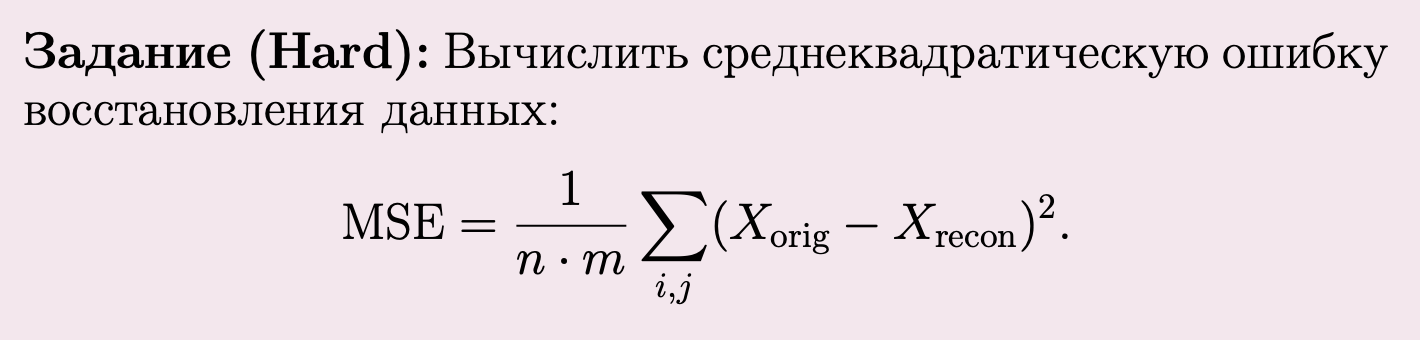

In [18]:
class Matrix (Matrix):
    def MSE (self, k):
        X_orig = self.center()

        X_recon = self.PCA(k)[0] * self.PCA(k)[2].trans()
        n = X_recon.height
        m = X_recon.width
        mse = sum((X_orig.matrix[i][j] - X_recon.matrix[i][j]) ** 2 for i in range(n) for j in range(m)) / (n * m)
        if abs(mse) < 1e-4:
            mse = float(f"{mse:.4e}")
        else:
            mse = round(mse, 4)
        return mse
        
        

In [19]:
matrix =  Matrix(3, 3, [[4, 2, 1],
                        [2, 3, 0.5],
                        [1, 0.5, 2]])
k = 2
mse = matrix.MSE(k)
print(f'MSE: {mse}')


MSE: 7.1915e-14


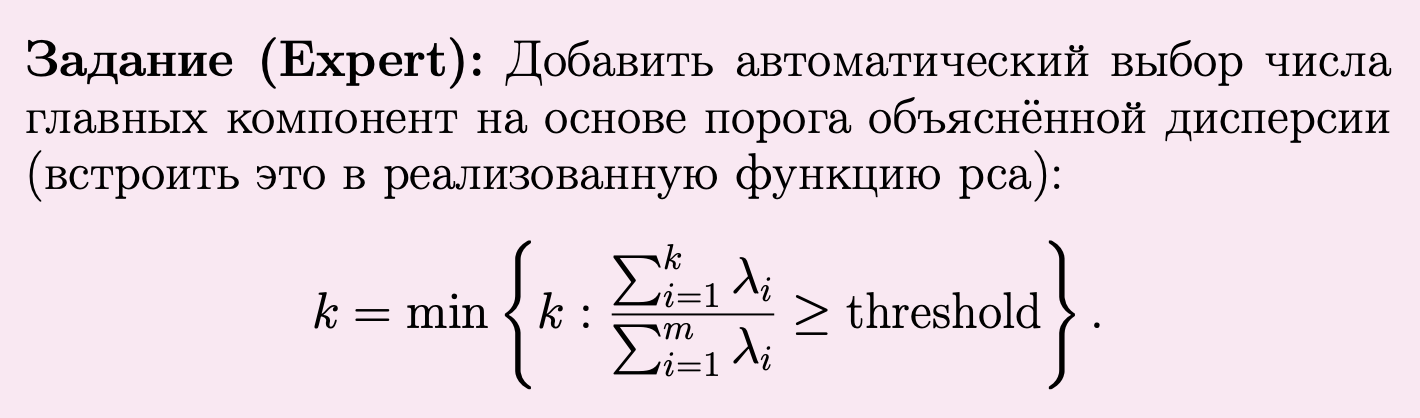

In [20]:
class Matrix(Matrix):
    def auto_select_k(self, threshold):
        eigenvalues = self.find_eigenvalues(-10, 10)
        s = sum(eigenvalues)
        s_k = 0
        for i in range(len(eigenvalues)):
            s_k += eigenvalues[i]
            if s_k / s >= threshold:
                return i + 1


In [21]:
matrix =  Matrix(3, 3, [[4, 2, 1],
                        [2, 3, 0.5],
                        [1, 0.5, 2]])
threshold = 0.95
print(f'Минимальный k: {matrix.auto_select_k(threshold)}')

Минимальный k: 3


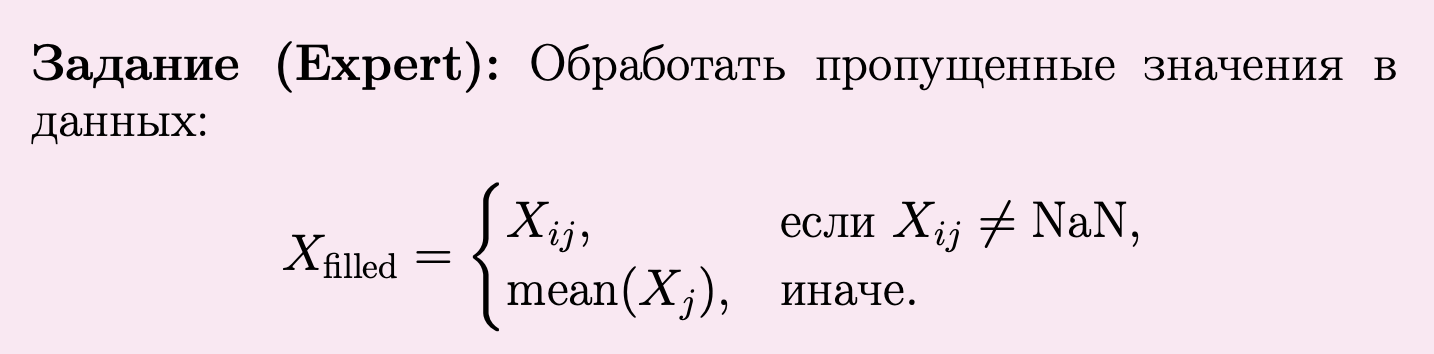

In [22]:
import math
class Matrix (Matrix):
    def not_NaN (self):
        mean = self.mean()
        new = copy.copy(self.matrix)
        
        for j in range(self.width):
            for i in range(self.height):
                if math.isnan(new[i][j]): 
                    new[i][j] = mean[j]
        return Matrix(self.height, self.width, new)

In [23]:
nan = math.nan
matrix =  Matrix(3, 3, [[4, nan, 1],
                        [2, nan, nan],
                        [1, 0.5, 2]])
print(matrix.not_NaN())

+------+------+------+
| 4.00 | 0.50 | 1.00 |
+------+------+------+
| 2.00 | 0.50 | 1.50 |
+------+------+------+
| 1.00 | 0.50 | 2.00 |
+------+------+------+


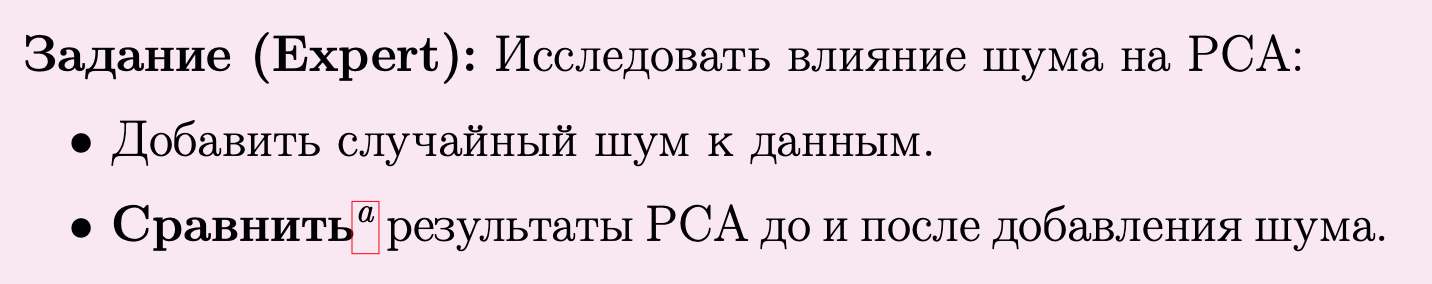

In [24]:
import random
class Matrix (Matrix):
    def get_column_std_devs (self):
        '''Вычисляет стандартное отклонение для каждого столбца'''
        column_stds = []
        n = self.height
        m = self.width
        column_means = self.mean()

        for j in range(m): 
            sum_sq_diff_from_mean = 0.0
            for i in range(n):
                element = self.matrix[i][j]
                diff_from_mean = element - column_means[j]
                sum_sq_diff_from_mean += diff_from_mean ** 2

            if n > 1:
                std_dev = math.sqrt(sum_sq_diff_from_mean / (n - 1))
            else: 
                 std_dev = 0.0
            column_stds.append(std_dev)
        
        return column_stds
    
    def add_noise_and_compare(self, k, noise_level):
        elem = copy.deepcopy(self.matrix)
        pca_elementary = self.PCA(k)
        column_stds = self.get_column_std_devs()

        for i in range(self.height): 
            for j in range(self.width): 
                random_noise = random.gauss(0, 1)

                scaled_noise = 0.0
                if column_stds[j] > 0:
                     scaled_noise = random_noise * noise_level * column_stds[j]

                elem[i][j] += scaled_noise

        noisy_matrix = Matrix(self.height, self.width, elem)
        try:
            pca_noise = noisy_matrix.PCA(k)
        except MatrixError as e:
            print(f"Ошибка при выполнении PCA на данных с шумом: {e}")
            self.matrix = elem
            return pca_elementary, math.nan

        return pca_elementary, pca_noise


In [25]:
matrix =  Matrix(3, 3, [[4, 2, 1],
                        [2, 3, 0.5],
                        [1, 0.5, 2]])
k = 2
noise = 0.1
ass = matrix.add_noise_and_compare(k, noise)

print('Результаты до добавления шума: ')
print(f'Проекция данных на главные компоненты:\n{ass[0][0]}')
print(f'\nРезультаты полсе добавления шума ({noise}): ')
print(f'Проекция данных на главные компоненты:\n{ass[1][0]}')

Результаты до добавления шума: 
Проекция данных на главные компоненты:
+-------+-------+
| -1.38 |  0.96 |
+-------+-------+
| -0.66 | -1.22 |
+-------+-------+
|  2.05 |  0.25 |
+-------+-------+

Результаты полсе добавления шума (0.1): 
Проекция данных на главные компоненты:
+-------+-------+
|  1.21 | -1.07 |
+-------+-------+
|  0.66 |  1.30 |
+-------+-------+
| -1.86 | -0.23 |
+-------+-------+


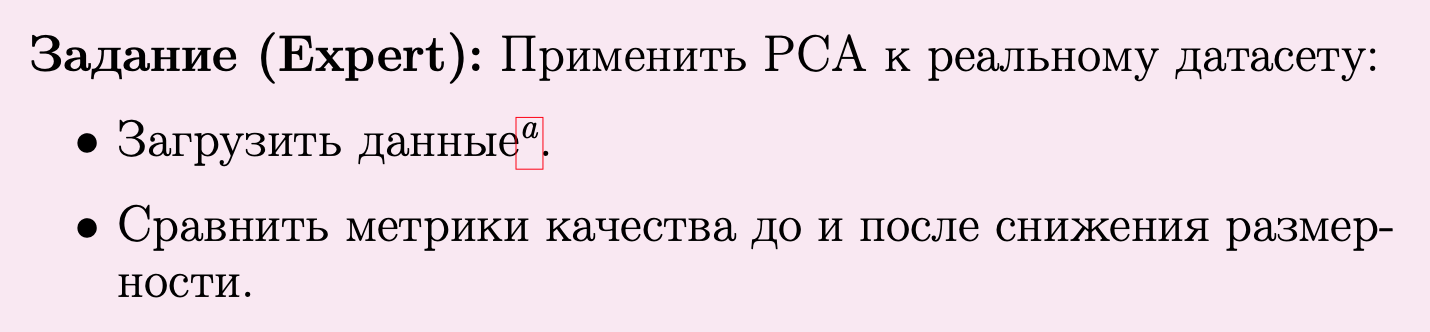

In [26]:
class Matrix (Matrix):
    def apply_pca_to_dataset(dataset_name, k):
        df = pd.read_csv(dataset_name)
        numeric_df = df.select_dtypes(include=[float, int])
        numeric_df = numeric_df.fillna(math.nan)
        matrix_data = numeric_df.values.tolist() 

        height = len(matrix_data)
        width = len(matrix_data[0]) if height > 0 else 0
        orig_m = Matrix(height, width, matrix_data)

        # Обработка пропущенных значений
        matrix = orig_m.not_NaN()

        # Применение PCA
        ass = matrix.PCA(k)

        return ass


In [27]:
file_path = 'bee_sperm.csv'
k = 4
resaults = Matrix.apply_pca_to_dataset(file_path, k)
print("\n--- Результаты PCA для вашего датасета ---")
print(f"Число выбранных главных компонент (k): {k}")
print("Проекция данных на главные компоненты:")
print(resaults[0])


--- Результаты PCA для вашего датасета ---
Число выбранных главных компонент (k): 4
Проекция данных на главные компоненты:
+-------+-------+-------+-------+
|  3.84 | -3.71 |  0.25 | -0.04 |
+-------+-------+-------+-------+
|  2.84 | -3.59 |  0.25 | -0.03 |
+-------+-------+-------+-------+
|  1.88 | -3.98 |  0.10 | -0.12 |
+-------+-------+-------+-------+
|  0.90 | -3.61 |  0.21 | -0.05 |
+-------+-------+-------+-------+
| -0.11 | -3.38 |  0.19 | -0.06 |
+-------+-------+-------+-------+
| -1.12 | -2.92 |  0.25 | -0.02 |
+-------+-------+-------+-------+
| -2.15 | -2.73 |  0.29 |  0.01 |
+-------+-------+-------+-------+
| -3.13 | -3.18 |  0.21 | -0.02 |
+-------+-------+-------+-------+
| -4.01 | -3.37 |  0.07 | -0.12 |
+-------+-------+-------+-------+
|  3.97 | -2.75 |  0.12 | -0.07 |
+-------+-------+-------+-------+
| -3.38 | -3.41 |  0.06 | -0.10 |
+-------+-------+-------+-------+
|  3.03 | -2.82 |  0.10 | -0.08 |
+-------+-------+-------+-------+
|  1.99 | -1.97 |  0.25 | 